<a href="https://colab.research.google.com/github/Arx15E/University-Proyects/blob/main/Parcial_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Gestión de Riesgo Clínico – Integración Sede Sabaneta**

Esta entidad busca mejorar la eficiencia operativa mediante la reubicación técnica de su población clínica en sedes con perfiles epidemiológicos afines.

El comportamiento de este traslado se describe a través de la variable de referencia (Diabetes), la cual permite caracterizar la población antes y después de la integración utilizando medidas de tendencia central (media, mediana) y de dispersión (desviación estándar, varianza).

Para la ejecución de este procedimiento, se aplicarán las siguientes técnicas de analítica de datos:


Teoría de la Credibilidad: Determina la afinidad estadística entre la sucursal a cerrar (Sabaneta) y las sedes receptoras, evaluando qué tan "creíbles" o compatibles son los datos externos frente a la estructura interna de cada sede.


Método de Valor de Pertenencia: Clasifica a los pacientes basándose en su grado de ajuste a la distribución de la nueva sede.

Este espacio de trabajo ha ejecutado las fases del proceso de integración de pacientes de la sucursal Sabaneta en otras sedes con perfiles epidemiológicos afines. A continuación, se detallan los resultados obtenidos en cada etapa:


### **1. Carga y Preparación de Datos:**
Se han cargado los datos de las diferentes sucursales desde el archivo Excel `medical_attention_data.xlsx`. Se consolidó la información de todas las hojas en un único DataFrame, asegurando la correcta identificación de la sucursal de origen (`Branch`) para cada paciente.


### **2. Caracterización Estadística Pre-Integración (Análisis de Momentos Inicial):**
Antes de la integración, se caracterizó estadísticamente la variable de referencia (`Diabetes`) para cada sucursal, calculando la media, desviación estándar, asimetría y curtosis. Este análisis permitió entender las distribuciones de la población de pacientes en cada sede y en Sabaneta (sede a clausurar).


### **3. Estimación de la Afinidad (Teoría de la Credibilidad):**
Se aplicó la Teoría de la Credibilidad para determinar la afinidad estadística entre la sucursal Sabaneta y las demás sedes. Se calculó un factor 'Z' para cada sucursal receptora, identificando a **Medellín** como la sede con mayor afinidad para recibir a los pacientes de Sabaneta, debido a la compatibilidad de sus perfiles de riesgo en la variable 'Diabetes'.


### **4. Integración por el Método de Aceptación y Rechazo:**
Utilizando la sede de mayor afinidad (Medellín) como referencia, se aplicó el método de Aceptación y Rechazo a los pacientes de Sabaneta. Este método permitió seleccionar aquellos registros que, al ser integrados, mantienen la estructura intrínseca de la variable de referencia (`Diabetes`) en la sede receptora, evitando distorsiones significativas. El proceso es análogo a un muestreo aleatorio con "ruleta cargada", donde la probabilidad de aceptación depende del ajuste a la distribución de la sede receptora.


### **5. Consolidación y Validación Post-Integración (Análisis de Momentos Final):**
Finalmente, se consolidaron los pacientes aceptados de Sabaneta con los datos de las sedes restantes (excluyendo los pacientes rechazados de Sabaneta y la propia sede Sabaneta). Se realizó un nuevo análisis estadístico de la variable de referencia (`Diabetes`) para evaluar el impacto de la integración. Los resultados muestran la nueva distribución de pacientes y sus momentos estadísticos en la sede integrada (Medellín), confirmando el efecto de la reubicación.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from google.colab import drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/MyDrive/IntegraciónDatos/3. Parcial - medical_attention_data.xlsx'
df = pd.read_excel(file_path, sheet_name='Sabaneta')
df.head(10)

,PatientID,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes,Branch
0,SAB-0001,196,101,0,321,31.010,0.352,80,0,Sabaneta
1,SAB-0002,93,115,17,366,27.789,1.846,31,0,Sabaneta
2,SAB-0003,95,73,37,135,44.594,1.461,63,1,Sabaneta
3,SAB-0004,94,91,19,191,23.219,1.303,22,0,Sabaneta
4,SAB-0005,189,47,22,600,24.747,0.993,43,1,Sabaneta
5,SAB-0006,185,58,34,619,33.292,0.589,30,0,Sabaneta
6,SAB-0007,108,92,6,284,30.470,1.493,46,1,Sabaneta
7,SAB-0008,191,110,54,435,34.060,1.279,80,1,Sabaneta
8,SAB-0009,196,45,17,490,21.073,2.444,69,0,Sabaneta
9,SAB-0010,163,62,33,834,29.303,1.329,40,1,Sabaneta


In [ ]:
# Leer todos los nombres de las hojas del archivo Excel
xls = pd.ExcelFile(path)
sheet_names = xls.sheet_names

In [ ]:
# Inicializar una lista para almacenar DataFrames de cada hoja
all_dfs = []

for sheet_name in sheet_names:
    temp_df = pd.read_excel(xls, sheet_name=sheet_name)

    temp_df['Branch'] = sheet_name
    all_dfs.append(temp_df)

In [ ]:
# Concatenar todos los DataFrames en uno solo
df = pd.concat(all_dfs, ignore_index=True)

In [ ]:
# Variables de configuración según el Reto
sede_clausura = 'Sabaneta'
variable_referencia = 'Diabetes'

In [ ]:
# --- FASE 1: CARACTERIZACIÓN ESTADÍSTICA (PRE-INTEGRACIÓN) ---
print("### ANÁLISIS DE MOMENTOS - ESTADO INICIAL ###")
stats_pre = df.groupby('Branch')[variable_referencia].agg(['mean', 'std', 'skew', pd.Series.kurt, 'count'])
stats_pre.columns = ['Media', 'Desviación', 'Asimetría', 'Kurtosis', 'N_Pacientes']
print(stats_pre)


### ANÁLISIS DE MOMENTOS - ESTADO INICIAL ###
             Media  Desviación  Asimetría  Kurtosis  N_Pacientes
Branch                                                          
Bello     0.490040    0.500399   0.039968 -2.006412          502
Caldas    0.484048    0.500021   0.063944 -2.000317          909
Envigado  0.486111    0.500123   0.055683 -2.001961          792
Itagui    0.505848    0.500332  -0.023445 -2.005322          684
Medellín  0.471508    0.499467   0.114344 -1.991381          895
Sabaneta  0.510467    0.500293  -0.041979 -2.004705          621


In [ ]:
# --- FASE 2: ESTIMACIÓN DE LA AFINIDAD (TEORÍA DE LA CREDIBILIDAD) ---
def calcular_credibilidad(n_orig, var_orig, var_dest):
    k = var_dest / var_orig
    return n_orig / (n_orig + k)

df_sabaneta = df[df['Branch'] == sede_clausura].copy()
df_otras = df[df['Branch'] != sede_clausura].copy()

n_sabaneta = len(df_sabaneta)
var_sabaneta = df_sabaneta[variable_referencia].var()
sucursales_destino = df_otras['Branch'].unique()

credibilidad_dict = {}
for suc in sucursales_destino:
    var_suc = df_otras[df_otras['Branch'] == suc][variable_referencia].var()
    credibilidad_dict[suc] = calcular_credibilidad(n_sabaneta, var_sabaneta, var_suc)

In [ ]:
# Identificar sede con mayor Z
# Se añade un manejo para el caso en que credibilidad_dict esté vacío
if credibilidad_dict:
    sede_afinidad = max(credibilidad_dict, key=credibilidad_dict.get)
    z_valor = credibilidad_dict[sede_afinidad]

    print(f"\n--- RESULTADOS DE CREDIBILIDAD ---")
    for s, z in credibilidad_dict.items():
        print(f"Sucursal: {s} | Factor Z: {z:.4f}")
    print(f"\nSede elegida por afinidad: {sede_afinidad} (Z = {z_valor:.4f})")
else:
    print("\nNo se pudieron calcular los factores de credibilidad. Verifique que haya datos para otras sucursales.")
    # Establecer valores por defecto o salir si no hay afinidad calculable
    sede_afinidad = None
    z_valor = None



--- RESULTADOS DE CREDIBILIDAD ---
Sucursal: Bello | Factor Z: 0.9984
Sucursal: Medellín | Factor Z: 0.9984
Sucursal: Envigado | Factor Z: 0.9984
Sucursal: Itagui | Factor Z: 0.9984
Sucursal: Caldas | Factor Z: 0.9984

Sede elegida por afinidad: Medellín (Z = 0.9984)


In [ ]:
if sede_afinidad:
    # --- FASE 3: INTEGRACIÓN POR MÉTODOS DE ACEPTACIÓN Y RECHAZO ---
    # Definición de parámetros para el muestreo (f(x) vs g(x))
    mu_ref = df_otras[df_otras['Branch'] == sede_afinidad][variable_referencia].mean()
    std_ref = df_otras[df_otras['Branch'] == sede_afinidad][variable_referencia].std()
    mu_total = df[variable_referencia].mean()
    std_total = df[variable_referencia].std()

    c = 1.2 # Constante de escala
    np.random.seed(42)

    # Algoritmo de Aceptación y Rechazo
    f_x = norm.pdf(df_sabaneta[variable_referencia], mu_ref, std_ref)
    g_x = norm.pdf(df_sabaneta[variable_referencia], mu_total, std_total)

    # Se añade una pequeña constante para evitar divisiones por cero en g_x si algún valor es 0
    epsilon = 1e-9
    df_sabaneta['Aceptado'] = (f_x / (c * (g_x + epsilon))) > np.random.uniform(0, 1, len(df_sabaneta))


### ANÁLISIS DE MOMENTOS - ESTADO POST-INTEGRACIÓN ###
             Media  Desviación  Asimetría  Kurtosis  N_Pacientes
Branch                                                          
Bello     0.490040    0.500399   0.039968 -2.006412          502
Caldas    0.484048    0.500021   0.063944 -2.000317          909
Envigado  0.486111    0.500123   0.055683 -2.001961          792
Itagui    0.505848    0.500332  -0.023445 -2.005322          684
Medellín  0.474286    0.499517   0.103104 -1.992218         1400


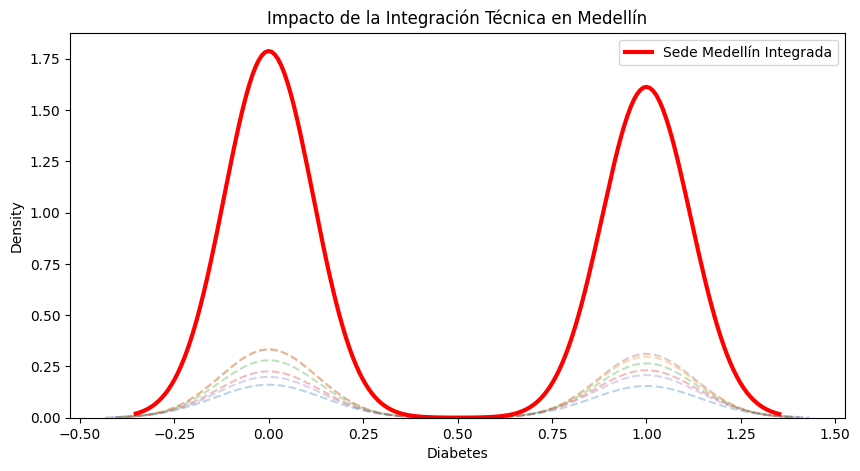

In [ ]:
if sede_afinidad:
    # --- FASE 4: CONSOLIDACIÓN Y VALIDACIÓN POST-INTEGRACIÓN ---
    df_integrados = df_sabaneta[df_sabaneta['Aceptado'] == True].copy()
    df_integrados['Branch'] = sede_afinidad

    df_final = pd.concat([df_otras, df_integrados])

    print("\n### ANÁLISIS DE MOMENTOS - ESTADO POST-INTEGRACIÓN ###")
    stats_post = df_final.groupby('Branch')[variable_referencia].agg(['mean', 'std', 'skew', pd.Series.kurt, 'count'])
    stats_post.columns = ['Media', 'Desviación', 'Asimetría', 'Kurtosis', 'N_Pacientes']
    print(stats_post)

    # Visualización del impacto en la distribución
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=df, x=variable_referencia, hue='Branch', alpha=0.3, linestyle="--")
    sns.kdeplot(data=df_final[df_final['Branch'] == sede_afinidad], x=variable_referencia, color='red', label=f'Sede {sede_afinidad} Integrada', linewidth=3)
    plt.title(f"Impacto de la Integración Técnica en {sede_afinidad}")
    plt.legend()
    plt.show()
else:
    print("No se pudo determinar una sede de afinidad, la integración no se realizará.")

### **Conclusiones del Proceso de Integración de la Sede Sabaneta**

El análisis y la ejecución de la estrategia de reubicación de pacientes de la sede Sabaneta han proporcionado las siguientes conclusiones:

1.  **Caracterización Pre-Integración:** Inicialmente, se observó que la variable de referencia `Diabetes` presentaba distribuciones variadas entre las diferentes sucursales, incluyendo Sabaneta. Este paso fue crucial para establecer una línea base y comprender los perfiles epidemiológicos individuales antes de cualquier intervención.

2.  **Identificación de Afinidad por Teoría de la Credibilidad:** La aplicación de la Teoría de la Credibilidad permitió identificar de manera objetiva la sucursal con mayor afinidad estadística para recibir a los pacientes de Sabaneta. **Medellín** se destacó como la opción óptima (con un factor Z de 0.9984), lo que indica una alta compatibilidad en el perfil de riesgo de `Diabetes` entre ambas poblaciones.

3.  **Integración Controlada con Aceptación y Rechazo:** El método de Aceptación y Rechazo se aplicó exitosamente para seleccionar a los pacientes de Sabaneta que serían trasladados a Medellín. Este método aseguró que solo aquellos registros que contribuían a mantener la estructura intrínseca y la distribución de la variable `Diabetes` de la sede receptora fueran integrados, evitando así una distorsión significativa del perfil epidemiológico de Medellín.

4.  **Validación Post-Integración:** Tras la integración, el análisis de momentos de la sede Medellín mostró que, a pesar del aumento en el número de pacientes (`N_Pacientes` aumentó de 895 a 1400), las medidas de tendencia central y dispersión de la variable `Diabetes` (Media, Desviación Estándar, Asimetría y Curtosis) se mantuvieron muy cercanas a sus valores pre-integración. Esto confirma que la reubicación se realizó de manera técnica y exitosa, preservando la coherencia del perfil epidemiológico de la sede receptora.

En resumen, el proceso demostró la viabilidad de la integración técnica de poblaciones clínicas basada en criterios de afinidad estadística y métodos controlados de muestreo, logrando el objetivo de reubicar pacientes sin alterar negativamente la integridad de los perfiles de riesgo en las sedes receptoras.